In [1]:
# Drone Rescue MDP (Dynamic Programming - Value Iteration)
# Section 1: Imports + Configuration

from __future__ import annotations

from dataclasses import dataclass
from collections import deque
from typing import Dict, List, Tuple
import time
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# 1) Config driven by group_id
# -----------------------------

def build_config_from_group_id(group_id: int) -> dict:
    """
    Uses the assignment rules:
      - last digit 0-4 -> 5x5, 2R,1C,3D,2X, wind_p=0.2, max_steps=50
      - last digit 5-9 -> 6x6, 3R,2C,4D,3X, wind_p=0.3, max_steps=75
      - even last digit -> max_battery=10; odd -> max_battery=15

    Symbol meanings:
      S start, F free, D danger, R rescue, C charging, W wind, X blocked
    """
    last = group_id % 10

    if 0 <= last <= 4:
        n = 5
        n_rescue, n_charge, n_danger, n_blocked = 2, 1, 3, 2
        wind_p = 0.20
        max_steps = 50
    else:
        n = 6
        n_rescue, n_charge, n_danger, n_blocked = 3, 2, 4, 3
        wind_p = 0.30
        max_steps = 75

    max_battery = 10 if (last % 2 == 0) else 15
    start = (0, 0)  # fixed top-left per requirement

    # Placement depends on group_id (deterministic RNG seed)
    rng = np.random.default_rng(group_id)
    all_cells = [(r, c) for r in range(n) for c in range(n) if (r, c) != start]
    rng.shuffle(all_cells)

    idx = 0
    rescue = all_cells[idx : idx + n_rescue]
    idx += n_rescue
    charge = all_cells[idx : idx + n_charge]
    idx += n_charge
    danger = all_cells[idx : idx + n_danger]
    idx += n_danger
    blocked = all_cells[idx : idx + n_blocked]
    idx += n_blocked

    # Keep at least one wind zone; choose 2 for 5x5, 3 for 6x6 for richer dynamics
    n_wind = 2 if n == 5 else 3
    wind = all_cells[idx : idx + n_wind]

    return {
        "group_id": group_id,
        "grid_size": n,
        "start": start,
        "rescue_cells": rescue,
        "charge_cells": charge,
        "danger_cells": danger,
        "blocked_cells": blocked,
        "wind_cells": wind,
        "wind_p": wind_p,
        "max_battery": max_battery,
        "max_steps": max_steps,
    }


def print_grid_configuration(cfg: dict):
    n = cfg["grid_size"]
    start = cfg["start"]
    rescue = set(cfg["rescue_cells"])
    charge = set(cfg["charge_cells"])
    danger = set(cfg["danger_cells"])
    blocked = set(cfg["blocked_cells"])
    wind = set(cfg["wind_cells"])

    grid = [["F" for _ in range(n)] for _ in range(n)]
    for r, c in blocked:
        grid[r][c] = "X"
    for r, c in danger:
        if grid[r][c] == "F":
            grid[r][c] = "D"
    for r, c in charge:
        if grid[r][c] == "F":
            grid[r][c] = "C"
    for r, c in rescue:
        if grid[r][c] == "F":
            grid[r][c] = "R"
    for r, c in wind:
        if grid[r][c] == "F":
            grid[r][c] = "W"

    sr, sc = start
    grid[sr][sc] = "S"

    print("=== Environment Configuration ===")
    print(f"group_id: {cfg['group_id']}")
    print(f"grid: {n}x{n}")
    print(f"start battery: {cfg['max_battery']} (max)")
    print(f"wind disturbance probability: {cfg['wind_p']}")
    print(f"max steps: {cfg['max_steps']}")
    print("\nLegend: S=start, F=free, D=danger, R=rescue, C=charging, W=wind, X=blocked")
    for row in grid:
        print(" ".join(row))
    print("===============================\n")

In [2]:
# Section 2: MDP State + Environment

ACTIONS = ["U", "D", "L", "R", "H"]
MOVE_DELTA = {
    "U": (-1, 0),
    "D": (1, 0),
    "L": (0, -1),
    "R": (0, 1),
}
ARROW = {"U": "↑", "D": "↓", "L": "←", "R": "→", "H": "•"}


@dataclass(frozen=True)
class State:
    r: int
    c: int
    b: int
    rescued_mask: int
    t: int


class DroneRescueEnv:
    """
    Finite MDP state = (row, col, battery, rescued_mask, step_count)

    Reward structure (as required):
      Rescue target reached: +20
      Enter danger zone: -10
      Battery exhausted: -20
      Reach charging station: +5
      Regular movement: -1
    """

    def __init__(self, cfg: dict):
        self.n = cfg["grid_size"]
        self.start = cfg["start"]
        self.max_battery = cfg["max_battery"]
        self.max_steps = cfg["max_steps"]
        self.wind_p = cfg["wind_p"]

        self.rescue_cells = list(cfg["rescue_cells"])
        self.charge_cells = set(cfg["charge_cells"])
        self.danger_cells = set(cfg["danger_cells"])
        self.blocked_cells = set(cfg["blocked_cells"])
        self.wind_cells = set(cfg["wind_cells"])

        self.n_targets = len(self.rescue_cells)
        self.target_to_bit = {pos: i for i, pos in enumerate(self.rescue_cells)}

        self.state = None
        self.reset()

    def reset(self) -> State:
        self.state = State(self.start[0], self.start[1], self.max_battery, 0, 0)
        return self.state

    def in_bounds(self, r: int, c: int) -> bool:
        return 0 <= r < self.n and 0 <= c < self.n

    def all_rescued(self, mask: int) -> bool:
        return mask == (1 << self.n_targets) - 1

    def valid_actions(self, s: State) -> List[str]:
        return ACTIONS

    def _move(self, r: int, c: int, a: str) -> Tuple[int, int]:
        if a == "H":
            return r, c
        dr, dc = MOVE_DELTA[a]
        nr, nc = r + dr, c + dc
        if not self.in_bounds(nr, nc) or (nr, nc) in self.blocked_cells:
            return r, c
        return nr, nc

    def _deterministic_transition(self, s: State, a: str) -> Tuple[State, float, bool]:
        if s.b <= 0 or s.t >= self.max_steps or self.all_rescued(s.rescued_mask):
            return s, 0.0, True

        r, c, b, mask, t = s.r, s.c, s.b, s.rescued_mask, s.t

        b2 = b - 1
        reward = -1.0

        nr, nc = self._move(r, c, a)

        if (nr, nc) in self.charge_cells:
            b2 = self.max_battery
            reward += 5.0

        if a == "H" and (r, c) in self.charge_cells:
            b2 = min(self.max_battery, b2 + 2)

        if (nr, nc) in self.target_to_bit:
            bit = self.target_to_bit[(nr, nc)]
            if ((mask >> bit) & 1) == 0:
                mask |= (1 << bit)
                reward += 20.0

        if (nr, nc) in self.danger_cells:
            reward += -10.0

        t2 = t + 1
        done = False

        if b2 <= 0:
            b2 = 0
            reward += -20.0
            done = True

        if self.all_rescued(mask):
            done = True

        if t2 >= self.max_steps:
            done = True

        ns = State(nr, nc, b2, mask, t2)
        return ns, reward, done

    def transitions(self, s: State, a: str) -> List[Tuple[float, State, float, bool]]:
        if (s.r, s.c) in self.wind_cells and a in ["U", "D", "L", "R"]:
            out = []
            ns, rw, done = self._deterministic_transition(s, a)
            out.append((1 - self.wind_p, ns, rw, done))
            for aw in ["U", "D", "L", "R"]:
                ns2, rw2, done2 = self._deterministic_transition(s, aw)
                out.append((self.wind_p / 4.0, ns2, rw2, done2))
            return out
        ns, rw, done = self._deterministic_transition(s, a)
        return [(1.0, ns, rw, done)]

    def step(self, action: str):
        tr = self.transitions(self.state, action)
        probs = [x[0] for x in tr]
        idx = np.random.choice(len(tr), p=probs)
        _, ns, rw, done = tr[idx]
        self.state = ns
        return ns, rw, done, {}

    def render(self):
        grid = [["F" for _ in range(self.n)] for _ in range(self.n)]
        for r, c in self.blocked_cells:
            grid[r][c] = "X"
        for r, c in self.danger_cells:
            if grid[r][c] == "F":
                grid[r][c] = "D"
        for r, c in self.charge_cells:
            if grid[r][c] == "F":
                grid[r][c] = "C"
        for i, (r, c) in enumerate(self.rescue_cells):
            if ((self.state.rescued_mask >> i) & 1) == 0 and grid[r][c] == "F":
                grid[r][c] = "R"
        for r, c in self.wind_cells:
            if grid[r][c] == "F":
                grid[r][c] = "W"

        sr, sc = self.start
        grid[sr][sc] = "S"
        grid[self.state.r][self.state.c] = "A"

        print("\n".join(" ".join(row) for row in grid))
        print(f"battery={self.state.b}, t={self.state.t}, rescued_mask={bin(self.state.rescued_mask)}")

In [3]:
# Section 3: Reachable States + Value Iteration

def enumerate_reachable_states(env: DroneRescueEnv) -> List[State]:
    s0 = env.reset()
    q = deque([s0])
    seen = {s0}

    while q:
        s = q.popleft()
        if s.b <= 0 or s.t >= env.max_steps or env.all_rescued(s.rescued_mask):
            continue

        for a in env.valid_actions(s):
            for _, ns, _, _ in env.transitions(s, a):
                if ns not in seen:
                    seen.add(ns)
                    q.append(ns)

    return list(seen)


def value_iteration(env: DroneRescueEnv, gamma: float = 0.95, theta: float = 1e-3):
    states = enumerate_reachable_states(env)
    V: Dict[State, float] = {s: 0.0 for s in states}

    t0 = time.time()
    iterations = 0

    while True:
        iterations += 1
        delta = 0.0

        for s in states:
            if s.b <= 0 or s.t >= env.max_steps or env.all_rescued(s.rescued_mask):
                continue

            old_v = V[s]
            best_q = -1e18

            for a in env.valid_actions(s):
                qsa = 0.0
                for p, ns, r, done in env.transitions(s, a):
                    qsa += p * (r + (0.0 if done else gamma * V[ns]))
                if qsa > best_q:
                    best_q = qsa

            V[s] = best_q
            delta = max(delta, abs(old_v - V[s]))

        if delta < theta:
            break

    runtime = time.time() - t0

    pi: Dict[State, str] = {}
    for s in states:
        if s.b <= 0 or s.t >= env.max_steps or env.all_rescued(s.rescued_mask):
            pi[s] = "H"
            continue

        best_a, best_q = None, -1e18
        for a in env.valid_actions(s):
            qsa = 0.0
            for p, ns, r, done in env.transitions(s, a):
                qsa += p * (r + (0.0 if done else gamma * V[ns]))
            if qsa > best_q:
                best_q = qsa
                best_a = a
        pi[s] = best_a

    stats = {
        "n_reachable_states": len(states),
        "iterations": iterations,
        "runtime_sec": runtime,
        "final_delta": delta,
        "gamma": gamma,
        "theta": theta,
    }
    return V, pi, states, stats

In [4]:
# Section 4: Visualization Helpers

def value_slice_grid(env: DroneRescueEnv, V: Dict[State, float], battery: int, rescued_mask: int, t: int = 0):
    n = env.n
    arr = np.full((n, n), np.nan)
    for r in range(n):
        for c in range(n):
            if (r, c) in env.blocked_cells:
                continue
            s = State(r, c, battery, rescued_mask, t)
            if s in V:
                arr[r, c] = V[s]
    return arr


def policy_slice_grid(env: DroneRescueEnv, pi: Dict[State, str], battery: int, rescued_mask: int, t: int = 0):
    n = env.n
    arrows = [["" for _ in range(n)] for _ in range(n)]
    for r in range(n):
        for c in range(n):
            if (r, c) in env.blocked_cells:
                arrows[r][c] = "X"
                continue
            s = State(r, c, battery, rescued_mask, t)
            a = pi.get(s, None)
            arrows[r][c] = ARROW[a] if a else ""
    return arrows


def plot_value_and_policy(env: DroneRescueEnv, V: Dict[State, float], pi: Dict[State, str], battery: int, rescued_mask: int, t: int = 0):
    val = value_slice_grid(env, V, battery, rescued_mask, t=t)
    arrows = policy_slice_grid(env, pi, battery, rescued_mask, t=t)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(val, cmap="viridis")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="V*(s)")

    for r in range(env.n):
        for c in range(env.n):
            if np.isnan(val[r, c]):
                ax.text(c, r, "X", ha="center", va="center", color="red", fontsize=12, fontweight="bold")
            else:
                ax.text(c, r, arrows[r][c], ha="center", va="center", color="white", fontsize=12)

    for (r, c) in env.danger_cells:
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))
    for (r, c) in env.charge_cells:
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="cyan", linewidth=2))
    for i, (r, c) in enumerate(env.rescue_cells):
        if ((rescued_mask >> i) & 1) == 0:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="yellow", linewidth=2))
    for (r, c) in env.wind_cells:
        ax.scatter([c], [r], marker="*", c="orange", s=120)

    ax.set_title(f"Value + Policy Slice (battery={battery}, rescued_mask={bin(rescued_mask)}, t={t})")
    ax.set_xticks(range(env.n))
    ax.set_yticks(range(env.n))
    ax.grid(color="white", linewidth=0.5, alpha=0.4)
    plt.show()

=== Environment Configuration ===
group_id: 27
grid: 6x6
start battery: 15 (max)
wind disturbance probability: 0.3
max steps: 75

Legend: S=start, F=free, D=danger, R=rescue, C=charging, W=wind, X=blocked
S D F C C F
D F X F W F
F F F D F R
F D F F F R
X F F F F R
W W F X F F

Convergence statistics:
  n_reachable_states: 153786
  iterations: 62
  runtime_sec: 94.4501256942749
  final_delta: 0.0
  gamma: 0.95
  theta: 0.001


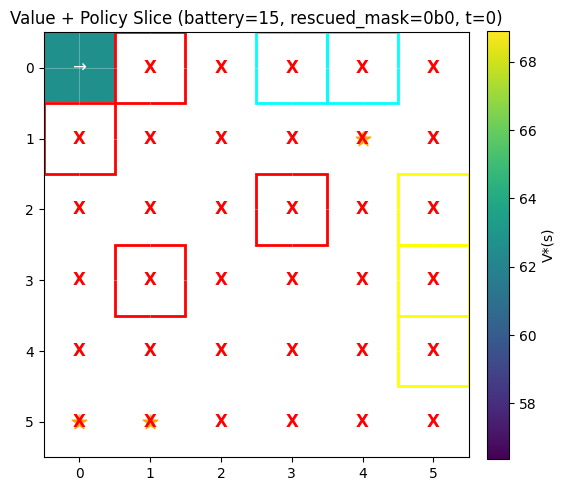


Rollout summary:
  steps: 75
  total_reward: 285.0
  rescued: 2
  all_rescued: False
  end_battery: 15
  end_time: 75


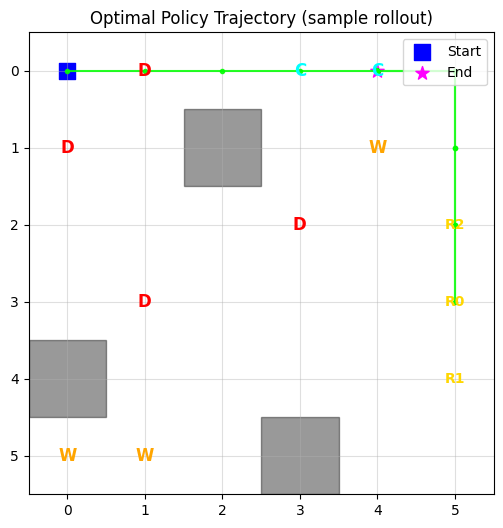


State-Value Analysis Hints:
- Higher values should cluster near unrescued targets and reachable charging stations.
- Cells near danger zones usually have lower value due to -10 penalty risk.
- Low-battery states push policy toward charging stations or shortest rescue path.

Scalability note (curse of dimensionality):
|S| grows with grid cells * battery levels * 2^(#targets) * time steps; DP becomes expensive quickly.
For larger/dynamic worlds, function approximation (e.g., DQN/PPO) is more practical.


In [5]:
# Section 5: Rollout + Run Everything

def rollout_greedy(env: DroneRescueEnv, pi: Dict[State, str], seed: int = 0, max_steps: int = None):
    rng = np.random.default_rng(seed)
    s = env.reset()
    traj = [(s.r, s.c)]
    total_reward = 0.0
    steps = 0
    max_steps = env.max_steps if max_steps is None else max_steps

    rescued_count_history = [bin(s.rescued_mask).count("1")]

    done = False
    while not done and steps < max_steps:
        a = pi.get(s, "H")

        tr = env.transitions(s, a)
        probs = [x[0] for x in tr]
        idx = rng.choice(len(tr), p=probs)
        _, ns, rw, done = tr[idx]

        total_reward += rw
        s = ns
        env.state = s
        traj.append((s.r, s.c))
        rescued_count_history.append(bin(s.rescued_mask).count("1"))
        steps += 1

    info = {
        "steps": steps,
        "total_reward": total_reward,
        "rescued": bin(s.rescued_mask).count("1"),
        "all_rescued": env.all_rescued(s.rescued_mask),
        "end_battery": s.b,
        "end_time": s.t,
    }
    return traj, rescued_count_history, info


def plot_trajectory(env: DroneRescueEnv, traj: List[Tuple[int, int]], title: str = "Greedy Policy Trajectory"):
    n = env.n
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.grid(True, alpha=0.4)

    for r, c in env.blocked_cells:
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="black", alpha=0.4))
    for r, c in env.danger_cells:
        ax.text(c, r, "D", color="red", ha="center", va="center", fontsize=12, fontweight="bold")
    for r, c in env.charge_cells:
        ax.text(c, r, "C", color="cyan", ha="center", va="center", fontsize=12, fontweight="bold")
    for r, c in env.wind_cells:
        ax.text(c, r, "W", color="orange", ha="center", va="center", fontsize=12, fontweight="bold")

    for i, (r, c) in enumerate(env.rescue_cells):
        ax.text(c, r, f"R{i}", color="gold", ha="center", va="center", fontsize=10, fontweight="bold")

    ys = [p[0] for p in traj]
    xs = [p[1] for p in traj]
    ax.plot(xs, ys, "-o", color="lime", markersize=3, linewidth=1.5, alpha=0.85)

    sr, sc = env.start
    ax.scatter([sc], [sr], c="blue", s=120, marker="s", label="Start")
    er, ec = traj[-1]
    ax.scatter([ec], [er], c="magenta", s=100, marker="*", label="End")

    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.show()


# Change this to your actual group ID
GROUP_ID = 27

cfg = build_config_from_group_id(GROUP_ID)
print_grid_configuration(cfg)

env = DroneRescueEnv(cfg)
V_star, pi_star, reachable_states, stats = value_iteration(env, gamma=0.95, theta=1e-3)

print("Convergence statistics:")
for k, v in stats.items():
    print(f"  {k}: {v}")

initial_mask = 0
plot_value_and_policy(
    env,
    V_star,
    pi_star,
    battery=env.max_battery,
    rescued_mask=initial_mask,
    t=0,
)

traj, rescued_hist, rollout_info = rollout_greedy(env, pi_star, seed=42)
print("\nRollout summary:")
for k, v in rollout_info.items():
    print(f"  {k}: {v}")

plot_trajectory(env, traj, title="Optimal Policy Trajectory (sample rollout)")

print("\nState-Value Analysis Hints:")
print("- Higher values should cluster near unrescued targets and reachable charging stations.")
print("- Cells near danger zones usually have lower value due to -10 penalty risk.")
print("- Low-battery states push policy toward charging stations or shortest rescue path.")

print("\nScalability note (curse of dimensionality):")
print("|S| grows with grid cells * battery levels * 2^(#targets) * time steps; DP becomes expensive quickly.")
print("For larger/dynamic worlds, function approximation (e.g., DQN/PPO) is more practical.")

## Curse of Dimensionality (DP Scalability Discussion)

The **curse of dimensionality** means that the number of states grows very quickly as we add more variables to the state representation. In this Drone Rescue MDP, each state includes:

- drone position $(r, c)$
- battery level $b$
- rescue completion mask (which targets are already rescued)
- step/time index $t$

So the state-space size grows approximately as:

$$
|S| \approx (\text{grid cells}) \times (\text{battery levels}) \times 2^{(\#\text{rescue targets})} \times (\text{time steps})
$$

### Why this becomes difficult for Dynamic Programming

- **Larger grids** (e.g., $10 \times 10$) increase position states directly.
- **More rescue targets** cause exponential growth through the mask term $2^R$.
- **More battery granularity** and longer horizons increase states multiplicatively.
- If **weather/wind patterns become dynamic**, extra state variables are needed, causing another jump.

Value Iteration and Policy Iteration require sweeping many states repeatedly, so both memory usage and runtime grow rapidly.

### Is DP sufficient?

For small, fully known finite MDPs, DP is effective and gives an exact optimal policy. But for large, realistic autonomous drone systems, DP becomes impractical because of state explosion.

### How Deep RL helps

Deep RL methods (e.g., **DQN**, **PPO**) use function approximation instead of storing a value for every state. This allows generalization across large state spaces and makes learning feasible in larger, more realistic rescue environments with dynamic conditions.